In [2]:
# used for initializing the shapelets via KMeans
# NOTE: if you are just looking for a working solution of the learning shapelets algorithm you are advised to just use the implementation that is already provided by tslearn.
! pip install --user tslearn matplotlib

DEPRECATION: pytorch-lightning 1.8.1 has a non-standard dependency specifier torch>=1.9.*. pip 23.3 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 23.2.1 -> 23.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Demo

The data set used is the FaceFour dataset of the UCR archive:
> Yanping Chen, Eamonn Keogh, Bing Hu, Nurjahan Begum, Anthony Bagnall, Abdullah Mueen and Gustavo Batista (2015). The UCR Time Series Classification Archive. URL www.cs.ucr.edu/~eamonn/time_series_data/.

### NOTE

To demonstrate the implementation, the shapelets to be learned are initialized
via K-Means as was done in the original paper. To do so, we use the K-Means implementation of the library TSLearn. If you are just looking for a working implementation of LearningShapelets, you are advised to just use the [TSLearn implementation](https://tslearn.readthedocs.io/en/latest/auto_examples/classification/plot_shapelet_distances.html). This repo just intends to provide an exemplary implementation using PyTorch.

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

# Path to root of this project, contains lots of modules
import sys
sys.path.insert(0, os.path.abspath('../'))
sys.path.insert(0, os.getcwd())

In [3]:
import math
import random
import numpy
from matplotlib import pyplot
from matplotlib import cm
from sklearn.preprocessing import StandardScaler
from tslearn.clustering import TimeSeriesKMeans
import torch
from torch import nn, optim

In [4]:
from src.learning_shapelets import LearningShapelets

### Load and Normalize Data

Helper functions to normalize the data:

In [5]:
def normalize_standard(X, scaler=None):
    shape = X.shape
    data_flat = X.flatten()
    if scaler is None:
        scaler = StandardScaler()
        data_transformed = scaler.fit_transform(data_flat.reshape(numpy.product(shape), 1)).reshape(shape)
    else:
        data_transformed = scaler.transform(data_flat.reshape(numpy.product(shape), 1)).reshape(shape)
    return data_transformed, scaler

def normalize_data(X, scaler=None):
    if scaler is None:
        X, scaler = normalize_standard(X)
    else:
        X, scaler = normalize_standard(X, scaler)
    
    return X, scaler

Load and normalize training data:

In [22]:
dataset = "FaceFour"
# print(dataset)

# Load training data
X_train = numpy.load(open(os.path.join('data', f'{dataset}_train.npy'), 'rb'))
print(f"X_train: {X_train}")
print(f"X_train: {X_train.size}")
print(f"Shape X_train: {X_train.shape}")
# load trainng data labels
y_train = numpy.load(open(os.path.join('data', f'{dataset}_train_labels.npy'), 'rb'))
# normalize training data
print(f"y_train: {y_train}")
# print(f"Shape X_train: {X_train.shape}")



X_train, scaler = normalize_data(X_train)
print(f"X_train: {X_train}")

print(f"Shape X_train: {X_train.shape}")
# print(f"Shape y_train: {y_train.shape}")

X_train: 8400
Shape X_train: (24, 1, 350)
y_train: [1 1 0 0 1 3 3 3 0 0 3 1 0 1 2 1 2 1 2 0 3 0 1 0]
X_train: [[[3.51570232 1.40286763 1.40286763 ... 2.31351218 2.31351218 2.31351218]]

 [[0.93405843 0.18853472 0.18853472 ... 1.23971629 1.23971629 1.23971629]]

 [[2.58431572 2.58431572 1.93322222 ... 2.14617395 2.14617395 2.58424802]]

 ...

 [[2.36208171 1.96471064 1.96471064 ... 2.49364329 2.49364329 2.49364329]]

 [[2.22048619 2.05223266 2.05223266 ... 0.64881887 0.64881887 1.85186311]]

 [[2.2540018  2.2540018  1.91957671 ... 1.85238746 1.85238746 2.35142498]]]
Shape X_train: (24, 1, 350)


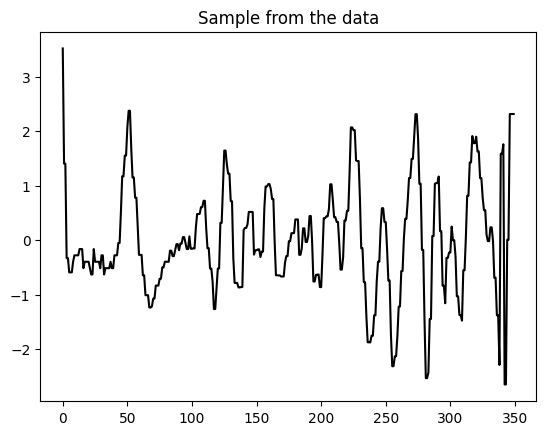

In [8]:
pyplot.title("Sample from the data")
pyplot.plot(X_train[0, 0], color='black')

### Initialize Model

In [9]:
def sample_ts_segments(X, shapelets_size, n_segments=10000):
    """
    Sample time series segments for k-Means.
    """
    n_ts, n_channels, len_ts = X.shape
    samples_i = random.choices(range(n_ts), k=n_segments)
    segments = numpy.empty((n_segments, n_channels, shapelets_size))
    for i, k in enumerate(samples_i):
        s = random.randint(0, len_ts - shapelets_size)
        segments[i] = X[k, :, s:s+shapelets_size]
    return segments

In [10]:
def get_weights_via_kmeans(X, shapelets_size, num_shapelets, n_segments=10000):
    """
    Get weights via k-Means for a block of shapelets.
    """
    segments = sample_ts_segments(X, shapelets_size, n_segments).transpose(0, 2, 1)
    k_means = TimeSeriesKMeans(n_clusters=num_shapelets, metric="euclidean", max_iter=50).fit(segments)
    clusters = k_means.cluster_centers_.transpose(0, 2, 1)
    return clusters

Initialize parameters:

In [11]:
n_ts, n_channels, len_ts = X_train.shape
loss_func = nn.CrossEntropyLoss()
num_classes = len(set(y_train))
# learn 2 shapelets of length 130
shapelets_size_and_len = {130: 2}
dist_measure = "euclidean"
lr = 1e-2
wd = 1e-3
epsilon = 1e-7
print(X_train.shape)
print(n_ts)
print(n_channels)
print(len_ts)
print(shapelets_size_and_len)

(24, 1, 350)
24
1
350
{130: 2}


Initialize model:

In [12]:
learning_shapelets = LearningShapelets(shapelets_size_and_len=shapelets_size_and_len,
                                       in_channels=n_channels,
                                       num_classes=num_classes,
                                       loss_func=loss_func,
                                       to_cuda=False,
                                       verbose=1,
                                       dist_measure=dist_measure)
                            
print(shapelets_size_and_len)
print(X_train.shape)

{130: 2}
(24, 1, 350)


Initialize shapelets via K-Means:

In [13]:
for i, (shapelets_size, num_shapelets) in enumerate(shapelets_size_and_len.items()):
    weights_block = get_weights_via_kmeans(X_train, shapelets_size, num_shapelets)
    learning_shapelets.set_shapelet_weights_of_block(i, weights_block)



Initialize optimizer:

In [14]:
optimizer = optim.Adam(learning_shapelets.model.parameters(), lr=lr, weight_decay=wd, eps=epsilon)
learning_shapelets.set_optimizer(optimizer)

### Train Model

Train the model:

In [15]:
losses = learning_shapelets.fit(X_train, y_train, epochs=2000, batch_size=256, shuffle=False, drop_last=False)

Loss: 0.10138744115829468: 100%|██████████| 2000/2000 [00:17<00:00, 116.88it/s]


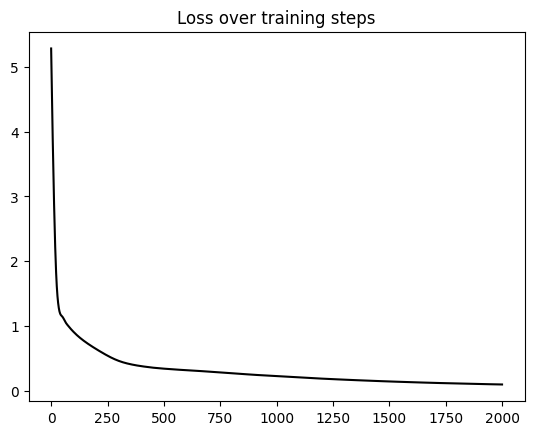

In [16]:
pyplot.plot(losses, color='black')
pyplot.title("Loss over training steps")
pyplot.show()

### Evaluate Model

In [17]:
def eval_accuracy(model, X, Y):
    predictions = model.predict(X)
    if len(predictions.shape) == 2:
        predictions = predictions.argmax(axis=1)
    print(f"Accuracy: {(predictions == Y).sum() / Y.size}")

Load test data:

In [18]:
# Load data set
X_test = numpy.load(open(os.path.join('data', f'{dataset}_test.npy'), 'rb'))
print(f"Shape X_train: {X_test.shape}")
y_test = numpy.load(open(os.path.join('data', f'{dataset}_test_labels.npy'), 'rb'))
# normalize data
X_train, scaler = normalize_data(X_train, scaler)

Shape X_train: (88, 1, 350)


In [19]:
eval_accuracy(learning_shapelets, X_test, y_test)

Accuracy: 0.875


### Visualize Shapelets & Decision Boundaries

Parts of the code here are copied from the TSLearn demo: https://tslearn.readthedocs.io/en/stable/auto_examples/classification/plot_shapelet_distances.html#sphx-glr-auto-examples-classification-plot-shapelet-distances-py

In [20]:
def torch_dist_ts_shapelet(ts, shapelet, cuda=True):
    """
    Calculate euclidean distance of shapelet to a time series via PyTorch and returns the distance along with the position in the time series.
    """
    if not isinstance(ts, torch.Tensor):
        ts = torch.tensor(ts, dtype=torch.float)
    if not isinstance(shapelet, torch.Tensor):
        shapelet = torch.tensor(shapelet, dtype=torch.float)
    if cuda:
        ts = ts.cuda()
        shapelet = shapelet.cuda()
    shapelet = torch.unsqueeze(shapelet, 0)
    # unfold time series to emulate sliding window
    ts = ts.unfold(1, shapelet.shape[2], 1)
    # calculate euclidean distance
    dists = torch.cdist(ts, shapelet, p=2)
    dists = torch.sum(dists, dim=0)
    # otherwise gradient will be None
    # hard min compared to soft-min from the paper
    d_min, d_argmin = torch.min(dists, 0)
    return (d_min.item(), d_argmin.item())

def lead_pad_shapelet(shapelet, pos):
    """
    Adding leading NaN values to shapelet to plot it on a time series at the best matching position.
    """
    pad = numpy.empty(pos)
    pad[:] = numpy.NaN
    padded_shapelet = numpy.concatenate([pad, shapelet])
    return padded_shapelet

Get the shapelets from the classifier:

In [21]:
shapelets = learning_shapelets.get_shapelets()

Apply shapelet transform and extract the distances of the dataset to the shapelets:

In [22]:
shapelet_transform = learning_shapelets.transform(X_test)
dist_s1 = shapelet_transform[:, 0]
dist_s2 = shapelet_transform[:, 1]

Extract the weights and biases of the linear layer to plot the decision boundaries:

In [23]:
weights, biases = learning_shapelets.get_weights_linear_layer()

Plot shapelets on top of their 10 best matches as well as a plot of the decision boundaries:

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

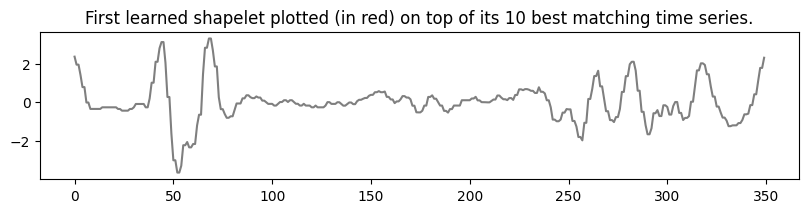

In [24]:
fig = pyplot.figure(facecolor='white')
fig.set_size_inches(20, 8)
gs = fig.add_gridspec(12, 8)
fig_ax1 = fig.add_subplot(gs[0:3, :4])
fig_ax1.set_title("First learned shapelet plotted (in red) on top of its 10 best matching time series.")
for i in numpy.argsort(dist_s1)[:10]:
    fig_ax1.plot(X_test[i, 0], color='black', alpha=0.5)
    _, pos = torch_dist_ts_shapelet(X_test[i], shapelets[0])
    fig_ax1.plot(lead_pad_shapelet(shapelets[0, 0], pos), color='#F03613', alpha=0.5)

fig_ax2 = fig.add_subplot(gs[0:3, 4:])
fig_ax2.set_title("Second learned shapelet plotted (in red) on top of its 10 best matching time series.")
for i in numpy.argsort(dist_s2)[:10]:
    fig_ax2.plot(X_test[i, 0], color='black', alpha=0.5)
    _, pos = torch_dist_ts_shapelet(X_test[i], shapelets[1])
    fig_ax2.plot(lead_pad_shapelet(shapelets[1, 0], pos), color='#F03613', alpha=0.5)


fig_ax3 = fig.add_subplot(gs[4:, :])
fig_ax3.set_title("The decision boundaries learned by the model to separate the four classes.")
color = {0: '#F03613', 1: '#7BD4CC', 2: '#00281F', 3: '#BEA42E'}
fig_ax3.scatter(dist_s1, dist_s2, color=[color[l] for l in y_test])


viridis = cm.get_cmap('viridis', 4)
# Create a meshgrid of the decision boundaries
xmin = numpy.min(shapelet_transform[:, 0]) - 0.1
xmax = numpy.max(shapelet_transform[:, 0]) + 0.1
ymin = numpy.min(shapelet_transform[:, 1]) - 0.1
ymax = numpy.max(shapelet_transform[:, 1]) + 0.1
xx, yy = numpy.meshgrid(numpy.arange(xmin, xmax, (xmax - xmin)/200),
                        numpy.arange(ymin, ymax, (ymax - ymin)/200))
Z = []
for x, y in numpy.c_[xx.ravel(), yy.ravel()]:
    Z.append(numpy.argmax([biases[i] + weights[i][0]*x + weights[i][1]*y
                           for i in range(4)]))
Z = numpy.array(Z).reshape(xx.shape)
fig_ax3.contourf(xx, yy, Z / 3, cmap=viridis, alpha=0.25)
fig_ax3.set_xlabel("$dist(x, s_1)$", fontsize=14)
fig_ax3.set_ylabel("$dist(x, s_2)$", fontsize=14)

caption = """Shapelets learned for the FaceFour dataset of the UCR archive plotted on top of the best matching time series (top two pictures).
        And the corresponding learned decision boundaries of the linear classifier on top of the shapelet transformed test data (bottom picture)."""
pyplot.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=14)
pyplot.savefig('learning_shapelets.png', facecolor=fig.get_facecolor(), bbox_inches="tight")
pyplot.show()